# AIS port-congestion demo, step by step

This notebook follows the proposed flow: raw AIS → hourly AIS and weather features → a transparent congestion index → lag/time features → chronological train/test split → four model candidates → comparison with a simple baseline.

**Important scope:** the NOAA 2024 archive is U.S.-focused. This notebook uses the San Pedro Bay / Los Angeles area only as a hackathon method demo. Its congestion index is constructed from AIS behavior; it is not observed demurrage or an official congestion label, and it must not be presented as an India-port model.


## Step 1: Import the tools

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import xarray as xr

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Step 2: Find the project and the small AIS sample

In [2]:
here = Path.cwd()
PROJECT_ROOT = here if (here / 'ml').exists() else here.parent
AIS_DIR = PROJECT_ROOT / 'ml' / 'data' / 'raw'
MODEL_DIR = PROJECT_ROOT / 'ml' / 'models'

# The sample is seven consecutive daily NOAA files, Jan 1–7, 2024.
ais_files = sorted(AIS_DIR.glob('ais-2024-01-*.csv.zst'))
print('AIS folder:', AIS_DIR)
print('Daily files found:', len(ais_files))
for path in ais_files:
    print(' -', path.name, f'({path.stat().st_size / 1_000_000:.1f} MB)')

if not ais_files:
    raise FileNotFoundError(
        'No NOAA AIS sample found. Put the selected .csv.zst files in ml/data/raw/.'
    )


AIS folder: /Users/ankushkumarguptapahleja/Downloads/defacto_hackathon/ml/data/raw
Daily files found: 7
 - ais-2024-01-01.csv.zst (196.5 MB)
 - ais-2024-01-02.csv.zst (198.3 MB)
 - ais-2024-01-03.csv.zst (199.6 MB)
 - ais-2024-01-04.csv.zst (193.4 MB)
 - ais-2024-01-05.csv.zst (202.0 MB)
 - ais-2024-01-06.csv.zst (200.1 MB)
 - ais-2024-01-07.csv.zst (195.6 MB)


## Step 3: Choose the demo port area

The coordinates below are a bounding box around San Pedro Bay / Los Angeles. AIS messages outside this small rectangle are discarded as each file is read, so we do not hold the entire U.S. dataset in memory. These coordinates are not Indian ports.

In [3]:
# Approximate demo bounds: west, east, south, north (longitude/latitude)
WEST, EAST = -118.35, -118.10
SOUTH, NORTH = 33.65, 33.82
CHUNK_SIZE = 500_000

# NOAA fields used below. Other available columns are intentionally not loaded.
USECOLS = ['mmsi', 'base_date_time', 'latitude', 'longitude', 'sog']


## Step 4: Preview a few rows before processing

In [4]:
preview = pd.read_csv(
    ais_files[0], compression='zstd', usecols=USECOLS, nrows=5
)
preview


,mmsi,base_date_time,longitude,latitude,sog
0,338075892,2024-01-01 00:00:03,-70.25298,43.65322,0.0
1,367669550,2024-01-01 00:00:04,-123.38573,46.20031,0.0
2,367118980,2024-01-01 00:00:06,-90.40674,29.98534,0.0
3,367177840,2024-01-01 00:00:05,-75.17649,39.88654,0.0
4,367305420,2024-01-01 00:00:06,-64.95229,18.33273,0.0


## Step 5: Clean AIS messages and keep only the selected area

We convert the timestamp and numeric fields, remove invalid coordinates/speeds, and keep only the local port bounding box. A stationary message means speed over ground (SOG) is at most one knot.

In [5]:
def clean_and_filter(chunk):
    chunk = chunk.copy()
    chunk['base_date_time'] = pd.to_datetime(
        chunk['base_date_time'], errors='coerce', utc=True
    )
    for column in ['latitude', 'longitude', 'sog']:
        chunk[column] = pd.to_numeric(chunk[column], errors='coerce')

    chunk = chunk.dropna(subset=['mmsi', 'base_date_time', 'latitude', 'longitude', 'sog'])
    chunk = chunk[
        chunk['latitude'].between(SOUTH, NORTH)
        & chunk['longitude'].between(WEST, EAST)
        & chunk['sog'].between(0, 50)
    ]
    chunk['mmsi'] = chunk['mmsi'].astype(str)
    chunk = chunk.drop_duplicates(subset=['mmsi', 'base_date_time'])
    chunk['hour'] = chunk['base_date_time'].dt.floor('h')
    chunk['stationary'] = (chunk['sog'] <= 1).astype('int8')
    return chunk[['mmsi', 'hour', 'sog', 'stationary']]


## Step 6: Read the compressed daily files in chunks

Each file contains many U.S. AIS messages. Chunking means we process part of a file at a time instead of loading the entire file into memory.

In [6]:
vessel_hour_parts = []
rows_in_area = 0

for file_number, path in enumerate(ais_files, start=1):
    print(f'Processing {file_number}/{len(ais_files)}: {path.name}')
    for chunk in pd.read_csv(
        path,
        compression='zstd',
        usecols=USECOLS,
        chunksize=CHUNK_SIZE,
        low_memory=True,
    ):
        local = clean_and_filter(chunk)
        rows_in_area += len(local)
        if not local.empty:
            # First summarize each vessel within each hour. This prevents a
            # vessel sending many messages from counting as many vessels.
            per_vessel_hour = local.groupby(['hour', 'mmsi'], as_index=False).agg(
                avg_sog=('sog', 'mean'),
                stationary_ratio=('stationary', 'mean'),
            )
            vessel_hour_parts.append(per_vessel_hour)

if not vessel_hour_parts:
    raise ValueError(
        'No AIS messages fell inside the demo bounds. Check the data files and coordinates.'
    )

vessel_hour = pd.concat(vessel_hour_parts, ignore_index=True)
# Combine any vessel-hour records that crossed a chunk or file boundary.
vessel_hour = vessel_hour.groupby(['hour', 'mmsi'], as_index=False).agg(
    avg_sog=('avg_sog', 'mean'),
    stationary_ratio=('stationary_ratio', 'mean'),
)
print('Filtered AIS messages:', f'{rows_in_area:,}')
print('Unique vessel-hour rows:', f'{len(vessel_hour):,}')
vessel_hour.head()


Processing 1/7: ais-2024-01-01.csv.zst


Processing 2/7: ais-2024-01-02.csv.zst


Processing 3/7: ais-2024-01-03.csv.zst


Processing 4/7: ais-2024-01-04.csv.zst


Processing 5/7: ais-2024-01-05.csv.zst


Processing 6/7: ais-2024-01-06.csv.zst


Processing 7/7: ais-2024-01-07.csv.zst


Filtered AIS messages: 864,967
Unique vessel-hour rows: 36,194


,hour,mmsi,avg_sog,stationary_ratio
0,2024-01-01 00:00:00+00:00,227773360,0.053333,1.000000
1,2024-01-01 00:00:00+00:00,229960000,0.118421,1.000000
2,2024-01-01 00:00:00+00:00,235084298,3.077381,0.380952
3,2024-01-01 00:00:00+00:00,255806029,0.000000,1.000000
4,2024-01-01 00:00:00+00:00,256029000,0.000000,1.000000


## Step 7: Turn AIS messages into one row per hour

`unique_vessels`, `avg_speed`, and `stationary_ratio` summarize traffic in the selected area each hour. Empty hours are filled with zero for this demo; real deployments need separate AIS-coverage checks before treating an empty hour as no traffic.

In [7]:
hourly = vessel_hour.groupby('hour').agg(
    unique_vessels=('mmsi', 'nunique'),
    avg_speed=('avg_sog', 'mean'),
    stationary_ratio=('stationary_ratio', 'mean'),
)
full_hours = pd.date_range(
    hourly.index.min(), hourly.index.max(), freq='h', tz='UTC'
)
hourly = hourly.reindex(full_hours)
hourly.index.name = 'datetime_hour'
hourly['unique_vessels'] = hourly['unique_vessels'].fillna(0)
hourly['avg_speed'] = hourly['avg_speed'].fillna(0)
hourly['stationary_ratio'] = hourly['stationary_ratio'].fillna(0)

print('Hourly rows:', hourly.shape[0])
print('Date range:', hourly.index.min(), 'to', hourly.index.max())
hourly.head()


Hourly rows: 168
Date range: 2024-01-01 00:00:00+00:00 to 2024-01-07 23:00:00+00:00


,unique_vessels,avg_speed,stationary_ratio
datetime_hour,,,
2024-01-01 00:00:00+00:00,219,1.301193,0.860917
2024-01-01 01:00:00+00:00,208,0.854924,0.905182
2024-01-01 02:00:00+00:00,210,0.821628,0.933299
2024-01-01 03:00:00+00:00,205,0.339157,0.968719
2024-01-01 04:00:00+00:00,204,0.285571,0.962827


## Step 8: Load local weather and wave observations

Weather can affect vessel speed and port operations. This demo uses wind and gust observations from NOAA Pier J, plus wave height, wave periods, and water temperature from nearby NOAA buoy 46253. These are nearby observations, not measurements from every ship in the AIS box. We convert both sources to hourly UTC values and match them to the AIS hours.

In [8]:
PIER_WEATHER_PATH = AIS_DIR / 'prjc1h2024.nc'
WAVE_WEATHER_PATH = AIS_DIR / '46253h2024.txt.gz'

for weather_path in [PIER_WEATHER_PATH, WAVE_WEATHER_PATH]:
    if not weather_path.exists():
        raise FileNotFoundError(f'Missing weather data file: {weather_path}')

# Step A: read NOAA Pier J wind speed and gust observations.
pier_dataset = xr.open_dataset(PIER_WEATHER_PATH, decode_timedelta=False)
pier_weather = pier_dataset[['wind_spd', 'gust']].to_dataframe().reset_index()
pier_weather['time'] = pd.to_datetime(pier_weather['time'], utc=True)
pier_hourly = (
    pier_weather.set_index('time')[['wind_spd', 'gust']]
    .resample('h').agg({'wind_spd': 'mean', 'gust': 'max'})
    .rename(columns={'wind_spd': 'wind_speed_m_s', 'gust': 'wind_gust_m_s'})
)
pier_dataset.close()

# Step B: read wave height/period and water temperature from buoy 46253.
wave_column_names = [
    'year', 'month', 'day', 'hour', 'minute', 'wind_direction',
    'wind_speed', 'gust', 'wave_height_m', 'dominant_wave_period_s',
    'average_wave_period_s', 'mean_wave_direction', 'pressure',
    'air_temperature', 'water_temp_c', 'dew_point', 'visibility', 'tide',
]
wave_weather = pd.read_csv(
    WAVE_WEATHER_PATH, sep=r'\s+', comment='#', names=wave_column_names,
    compression='gzip',
)
wave_weather['time'] = pd.to_datetime({
    'year': wave_weather['year'], 'month': wave_weather['month'],
    'day': wave_weather['day'], 'hour': wave_weather['hour'],
    'minute': wave_weather['minute'],
}, utc=True)
# NOAA uses sentinel values to mean 'missing'; convert them before averaging.
wave_features = [
    'wave_height_m', 'dominant_wave_period_s',
    'average_wave_period_s', 'water_temp_c',
]
wave_weather[wave_features] = wave_weather[wave_features].replace(
    [99.0, 999.0, 9999.0], np.nan
)
wave_hourly = wave_weather.set_index('time')[wave_features].resample('h').mean()

# Step C: combine weather sources and align them to each AIS hour.
weather_hourly = pier_hourly.join(wave_hourly, how='outer')
hourly = hourly.join(weather_hourly, how='left')
weather_features = [
    'wind_speed_m_s', 'wind_gust_m_s', 'wave_height_m',
    'dominant_wave_period_s', 'average_wave_period_s', 'water_temp_c',
]
print('Hourly AIS rows with weather:', len(hourly))
print('Weather feature missing values:')
display(hourly[weather_features].isna().sum().rename('missing_hours').to_frame())
hourly[weather_features].head()


Hourly AIS rows with weather: 168
Weather feature missing values:


,missing_hours
wind_speed_m_s,0
wind_gust_m_s,0
wave_height_m,0
dominant_wave_period_s,0
average_wave_period_s,0
water_temp_c,0


,wind_speed_m_s,wind_gust_m_s,wave_height_m,dominant_wave_period_s,average_wave_period_s,water_temp_c
datetime_hour,,,,,,
2024-01-01 00:00:00+00:00,2.583333,4.1,1.465,13.025,9.545,16.90
2024-01-01 01:00:00+00:00,3.160000,4.4,1.350,14.835,9.170,16.90
2024-01-01 02:00:00+00:00,3.340000,4.3,1.315,12.915,9.430,16.90
2024-01-01 03:00:00+00:00,3.040000,4.4,1.325,13.395,9.580,16.85
2024-01-01 04:00:00+00:00,2.250000,3.9,1.340,13.025,9.895,16.80


## Step 9: Create a clear, rule-based congestion index

AIS does not contain a column called `congestion`. For this prototype, we create a 0–100 index from traffic count, stationary-vessel share, and low speed. This is a proxy label made by our own rule, not measured queue time or demurrage.

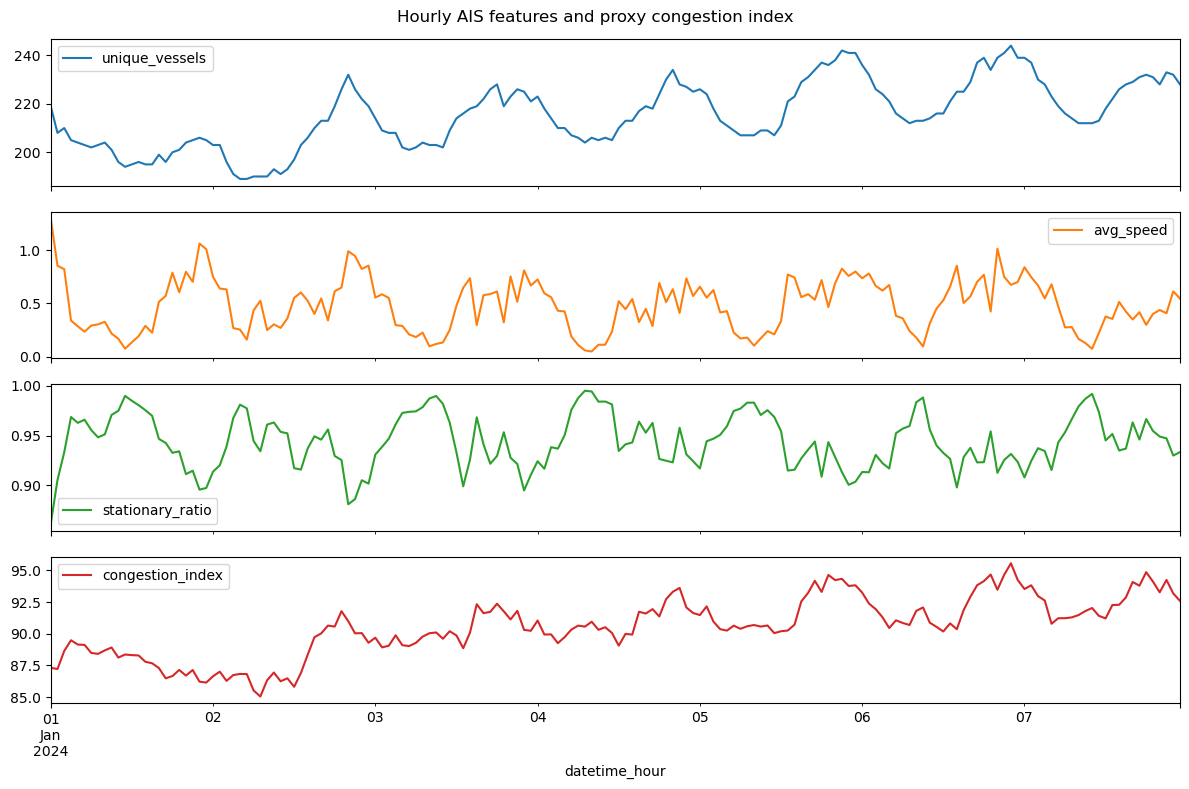

In [9]:
traffic_score = (hourly['unique_vessels'] / 250).clip(0, 1)
slow_score = (1 - hourly['avg_speed'] / 12).clip(0, 1)
hourly['congestion_index'] = 100 * (
    0.50 * traffic_score
    + 0.35 * hourly['stationary_ratio']
    + 0.15 * slow_score
)

hourly[['unique_vessels', 'avg_speed', 'stationary_ratio', 'congestion_index']].plot(
    subplots=True, figsize=(12, 8), title='Hourly AIS features and proxy congestion index'
)
plt.tight_layout()
plt.show()


## Step 10: Build past-only features and the next-hour answer

A lag is a value from an earlier hour. Rolling averages are shifted first so they do not accidentally use future values. The target for hour T is the congestion index at T+1.

In [10]:
features = hourly[['unique_vessels', 'avg_speed', 'stationary_ratio'] + weather_features].copy()
features['congestion_now'] = hourly['congestion_index']
features['hour'] = hourly.index.hour
features['day_of_week'] = hourly.index.dayofweek
features['month'] = hourly.index.month
features['day_of_year'] = hourly.index.dayofyear

past_congestion = hourly['congestion_index'].shift(1)
for lag in [1, 3, 6, 24]:
    features[f'congestion_lag_{lag}'] = hourly['congestion_index'].shift(lag)
for window in [3, 6, 24]:
    features[f'congestion_rolling_{window}'] = past_congestion.rolling(window).mean()

samples = features.copy()
samples['target_next_hour'] = hourly['congestion_index'].shift(-1)
samples = samples.replace([np.inf, -np.inf], np.nan).dropna()

X = samples.drop(columns='target_next_hour')
y = samples['target_next_hour']
print('ais_ml shape (feature rows, feature columns):', X.shape)
print('Target rows:', y.shape)
if X.empty:
    raise ValueError('ais_ml is empty. Need more consecutive AIS hours for lag features.')
X.head()


ais_ml shape (feature rows, feature columns): (143, 21)
Target rows: (143,)


,unique_vessels,avg_speed,stationary_ratio,wind_speed_m_s,wind_gust_m_s,wave_height_m,dominant_wave_period_s,average_wave_period_s,water_temp_c,congestion_now,...,day_of_week,month,day_of_year,congestion_lag_1,congestion_lag_3,congestion_lag_6,congestion_lag_24,congestion_rolling_3,congestion_rolling_6,congestion_rolling_24
datetime_hour,,,,,,,,,,,,,,,,,,,,,
2024-01-02 00:00:00+00:00,203,0.749868,0.913589,4.380000,5.1,0.755,13.330,9.160,16.95,86.638294,...,1,1,2,86.140037,87.132644,86.655595,87.305599,86.495827,86.662119,87.817324
2024-01-02 01:00:00+00:00,203,0.640123,0.920049,4.400000,5.2,0.725,13.330,9.205,16.90,87.001578,...,1,1,2,86.638294,86.214801,87.138155,87.212732,86.331044,86.659236,87.789519
2024-01-02 02:00:00+00:00,196,0.631757,0.938994,3.340000,5.6,0.695,12.500,8.860,16.80,86.275109,...,1,1,2,87.001578,86.140037,86.691483,88.638438,86.593303,86.636473,87.780721
2024-01-02 03:00:00+00:00,191,0.268771,0.967768,2.583333,4.6,0.815,12.915,5.850,16.80,86.735899,...,1,1,2,86.275109,86.638294,87.132644,89.481203,86.638327,86.567077,87.682249
2024-01-02 04:00:00+00:00,189,0.254012,0.981156,2.080000,3.7,0.820,13.330,5.825,16.80,86.822950,...,1,1,2,86.735899,87.001578,86.214801,89.141985,86.670862,86.500953,87.567861


## Step 11: Split by time, not at random

Earlier hours train the models and later hours test them. This avoids training on future records and testing on the past.

In [11]:
split_at = int(len(samples) * 0.80)
X_train, X_test = X.iloc[:split_at], X.iloc[split_at:]
y_train, y_test = y.iloc[:split_at], y.iloc[split_at:]

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))
print('Train ends:', X_train.index.max())
print('Test starts:', X_test.index.min())
if len(X_test) == 0:
    raise ValueError('Not enough hourly samples for a chronological test set.')


Training rows: 114
Testing rows: 29
Train ends: 2024-01-06 17:00:00+00:00
Test starts: 2024-01-06 18:00:00+00:00


## Step 12: Define the four model candidates

Linear Regression is the simple baseline model. Random Forest, XGBoost, and LightGBM can learn non-linear patterns. All candidates use the same training and test rows.

In [12]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Random Forest': RandomForestRegressor(
        n_estimators=150, max_depth=5, min_samples_leaf=3,
        random_state=42, n_jobs=-1,
    ),
    'XGBoost': XGBRegressor(
        objective='reg:squarederror', n_estimators=150,
        max_depth=3, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, random_state=42, n_jobs=-1,
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        num_leaves=7, random_state=42, verbosity=-1,
    ),
}


## Step 13: Train and compare the models

MAE and RMSE are errors on the 0–100 proxy index, so lower is better. R² is included for context but can be unstable on a very small sample. Persistence means predicting that the next hour will equal the current hour.

In [13]:
rows = []
trained_models = {}

baseline_prediction = X_test['congestion_now'].to_numpy()
rows.append({
    'model': 'Persistence baseline',
    'MAE': mean_absolute_error(y_test, baseline_prediction),
    'RMSE': mean_squared_error(y_test, baseline_prediction) ** 0.5,
    'R2': r2_score(y_test, baseline_prediction),
})

for name, candidate in models.items():
    candidate.fit(X_train, y_train)
    prediction = candidate.predict(X_test)
    trained_models[name] = candidate
    rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, prediction),
        'RMSE': mean_squared_error(y_test, prediction) ** 0.5,
        'R2': r2_score(y_test, prediction),
    })

results = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
results


,model,MAE,RMSE,R2
0,Persistence baseline,0.679417,0.813192,0.607702
1,Linear Regression,0.684731,0.854270,0.567067
2,Random Forest,0.705021,0.882770,0.537699
3,LightGBM,0.841115,1.037573,0.361343
4,XGBoost,0.952592,1.137599,0.232269


## Step 14: Pick the best candidate and inspect its errors

In [14]:
baseline_mae = results.loc[
    results['model'] == 'Persistence baseline', 'MAE'
].iloc[0]
model_results = results[results['model'] != 'Persistence baseline']
best_name = model_results.iloc[0]['model']
best_model = trained_models[best_name]
best_prediction = best_model.predict(X_test)
beats_baseline = float(model_results.iloc[0]['MAE']) < float(baseline_mae)

print('Best candidate:', best_name)
print('Beats persistence baseline:', beats_baseline)
pd.DataFrame({
    'actual_next_hour_index': y_test,
    'predicted_next_hour_index': best_prediction,
    'current_hour_index': X_test['congestion_now'],
}).head(12)


Best candidate: Linear Regression
Beats persistence baseline: False


,actual_next_hour_index,predicted_next_hour_index,current_hour_index
datetime_hour,,,
2024-01-06 18:00:00+00:00,94.667282,94.561149,94.149282
2024-01-06 19:00:00+00:00,93.468451,94.371352,94.667282
2024-01-06 20:00:00+00:00,94.649648,94.160150,93.468451
2024-01-06 21:00:00+00:00,95.559466,94.379583,94.649648
2024-01-06 22:00:00+00:00,94.243040,94.762887,95.559466
2024-01-06 23:00:00+00:00,93.524233,93.472252,94.243040
2024-01-07 00:00:00+00:00,93.819890,92.819274,93.524233
2024-01-07 01:00:00+00:00,92.967537,92.890991,93.819890
2024-01-07 02:00:00+00:00,92.619128,92.001200,92.967537


## Step 15: Save the demo model and training record

The saved artifact is explicitly named a demo model. A one-week U.S. sample and a proxy target are not sufficient to claim reliable India-port predictions.

In [15]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / 'ais_congestion_demo.joblib'
results_path = PROJECT_ROOT / 'ml' / 'ais_congestion_results.json'

joblib.dump(best_model, model_path)
report = {
    'source': 'NOAA MarineCadastre AIS 2024 + NOAA NDBC weather stations PRJC1 and 46253',
    'weather_features': weather_features,
    'weather_station_notes': 'Wind/gust from Los Angeles Pier J; waves/temperature from nearby San Pedro South buoy 46253.',
    'sample_dates': [path.name for path in ais_files],
    'demo_area': 'San Pedro Bay / Los Angeles, United States',
    'target': 'rule-based AIS congestion index one hour ahead (0-100)',
    'target_is_observed_demurrage': False,
    'training_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'selected_model': best_name,
    'beats_persistence_baseline': bool(beats_baseline),
    'metrics': results.to_dict(orient='records'),
    'limitation': 'Small one-week U.S. demo sample with nearby weather observations and a rule-based proxy target; not an India-port model or demurrage predictor.',
}
results_path.write_text(json.dumps(report, indent=2))
print('Saved model:', model_path)
print('Saved metrics:', results_path)


Saved model: /Users/ankushkumarguptapahleja/Downloads/defacto_hackathon/ml/models/ais_congestion_demo.joblib
Saved metrics: /Users/ankushkumarguptapahleja/Downloads/defacto_hackathon/ml/ais_congestion_results.json
